<a href="https://colab.research.google.com/github/ghadisaedi/ghadi/blob/main/Lab7_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Student Information
**Name:*غدي حسن الصاعدي*                
**ID:*4454741*

#AI342 Lab 7: Segmentation
### **Evolution of Learning: From Manual Implementation to OpenCV**

In our previous labs, we focused on the mathematical foundations by manually defining masks and using `Scipy` for convolution.
In this lab, we transition to **OpenCV (Open Source Computer Vision Library)**.


             "**Why OpenCV?**
* **Efficiency:** It is highly optimized for real-time applications.

* **Complexity:** It provides ready-to-use functions for advanced algorithms like Canny, Hough, and Adaptive Thresholding that are difficult to implement from scratch.

* **Industry Standard:** It is the primary library used in professional Computer Vision projects and research.

### Task 0: Preparation
*Run this to load libraries and the image.*

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, binary_dilation
from skimage import data


#Data Types:** Always use `np.float32` for normalization and `cv2.CV_32F` (or `ddepth=-1`) to maintain compatibility.

image = data.camera()
image_f = image.astype(np.float32) / 255.0
print("Environment Ready.")

Environment Ready.


### Task 1: Point Detection
**Goal:** Define point_mask, use convolve, apply threshold 0.3, and plot.

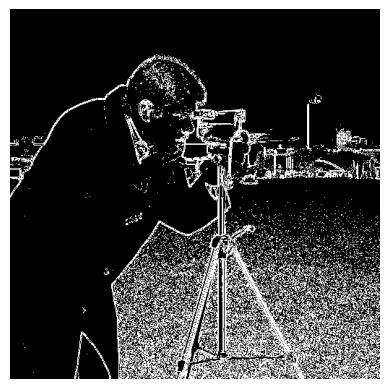

In [ ]:
# --- Task 1: Point Detection Implementation ---

# 1. Define the Point Detection Mask (3x3 Kernel)
# Instructions: Create a numpy array where the center pixel is 8 and all neighbors are -1.

kernel = np.array([[-1,-1,-1],
                   [-1, 8,-1],
                   [-1,-1,-1]], dtype=np.float32)
# 2. Apply Spatial Correlation/Convolution
# Method: Use the 'convolve' function from scipy.ndimage.
# Parameters: convolve(input_image, weights/mask)
response = convolve(image_f, kernel)

# 3. Apply Thresholding to find isolated points
# Instructions: Absolute the response and compare it to a threshold (tau).

tau = 0.3
points = np.abs(response) > tau


# 4. Display the results
# Method: Use plt.imshow(result, cmap='gray') to visualize the points detected.


plt.imshow(points, cmap='gray')
plt.axis('off')
plt.show()

**Q1: In the point detection mask, the sum of all coefficients is zero. Why is this necessary? Also, what will be the result (the response) when the mask is applied to a constant gray region?** *Answer:*
The zero sum makes the mask detect only changes, not uniform intensity.

On a constant gray region, the output is 0 everywhere because all values cancel out.

### Task 2: Line Detection
**Goal:** Define h_mask & v_mask, use convolve, apply threshold 0.4, and plot side-by-side.

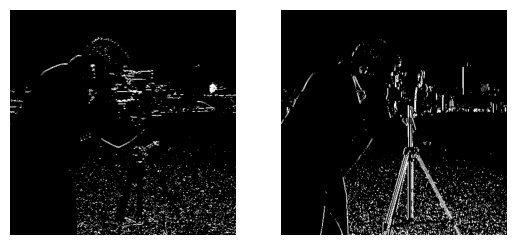

In [ ]:
# --- Task 2: Line Detection Implementation ---

# 1. Define the Horizontal Line Detection Mask (h_mask)
# Instructions: Create a 3x3 array where the middle ROW is [2, 2, 2] and others are -1.

h_mask = np.array([[-1,-1,-1],
                   [ 2, 2, 2],
                   [-1,-1,-1]], dtype=np.float32)

# 2. Define the Vertical Line Detection Mask (v_mask)
# Instructions: Create a 3x3 array where the middle COLUMN is [2, 2, 2] and others are -1.

v_mask = np.array([[-1, 2,-1],
                   [-1, 2,-1],
                   [-1, 2,-1]], dtype=np.float32)
# 3. Apply Convolution for both masks
# Method: Use convolve(image_f, h_mask) and convolve(image_f, v_mask).
h_response = convolve(image_f, h_mask)
v_response = convolve(image_f, v_mask)

# 4. Apply Thresholding
# Instructions: Use np.abs(response) > 0.4 to extract the strongest line responses.

h_lines = np.abs(h_response) > 0.4
v_lines = np.abs(v_response) > 0.4
# 5. Visualization
# Method: Use plt.subplot(1, 2, 1) for Horizontal and plt.subplot(1, 2, 2) for Vertical.
# Don't forget to use plt.imshow(..., cmap='gray').
plt.subplot(1,2,1)
plt.imshow(h_lines, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(v_lines, cmap='gray')
plt.axis('off')

plt.show()

**Q2: If an image contains both isolated noise points and long lines, how does the line detection mask help in emphasizing the lines while suppressing the noise points compared to the point detection mask?

*Answer:*
 The line detection mask responds strongly to structured, continuous patterns (horizontal or vertical alignment), so it highlights long lines while suppressing isolated pixels.

In contrast, the point detection mask responds to single isolated intensity changes, so it emphasizes noise points rather than lines.**

### **💡 Technical Concept: Image Depth (`ddepth`)**

When using OpenCV filters like **Sobel** or **Laplacian**, you must specify the **`ddepth`** parameter.

* **What is `ddepth`?** It defines the **Data Type** of the output image (the result of the filter).
* **Common Options:**
    * `cv2.CV_8U`: (8-bit unsigned integer) Values from 0 to 255.
    * `cv2.CV_32F` or `cv2.CV_64F`: (Float) Used for calculations involving negative numbers and decimals.
* **Why we use `-1`?** By setting `ddepth = -1`, we tell the function to make the **output image** have the **exact same data type** as the **input image**. Since our input is `float32`, the output will also be `float32`. This ensures compatibility and avoids errors.

### Task 3: Sobel & Laplacian
**Goal:** Use cv2.Sobel (-1), calculate magnitude, use cv2.Laplacian (-1), and plot both binary results.

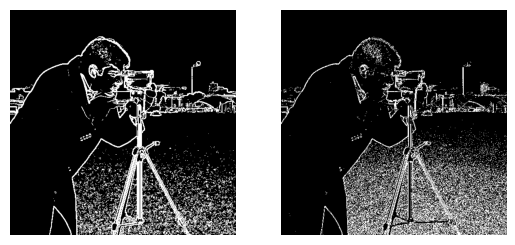

In [ ]:
# --- Task 3: Edge Detection using Sobel & Laplacian (cv2) ---

# 1. Compute Sobel Gradient in X direction
# Method: Use cv2.Sobel(src, ddepth, dx, dy, ksize)
# Parameters: image_f, ddepth=-1 (to match input), dx=1, dy=0, ksize=3
gx = cv2.Sobel(image_f, -1, 1, 0, ksize=3)
gy = cv2.Sobel(image_f, -1, 0, 1, ksize=3)


# 2. Compute Sobel Gradient in Y direction
# Parameters: image_f, ddepth=-1, dx=0, dy=1, ksize=3
mag = np.hypot(gx, gy)

# 3. Calculate the Gradient Magnitude
# Instructions: Combine gx and gy to get the total edge strength.
# Method: Use np.hypot(gx, gy) or np.sqrt(gx**2 + gy**2).
lap = cv2.Laplacian(image_f, -1)

# 4. Compute the Laplacian (2nd Derivative)
# Method: Use cv2.Laplacian(src, ddepth)
# Parameters: image_f, ddepth=-1
edges_sobel = mag > 0.4
edges_lap = np.abs(lap) > 0.15

# 5. Apply Thresholding and Display
# Instructions: Threshold both (Magnitude > 0.4) and (Abs Laplacian > 0.15).
# Plot the results side-by-side to compare 1st vs 2nd derivative edges.
plt.subplot(1,2,1)
plt.imshow(edges_sobel, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges_lap, cmap='gray')
plt.axis('off')

plt.show()

**Q3: How does the "thickness" and "continuity" of the edges in the Sobel result (1st derivative) differ from the Laplacian result (2nd derivative)?**
*Sobel (1st derivative) usually produces thicker and more continuous edges, because it captures directional gradients (x and y) and combines them smoothly.

Laplacian (2nd derivative) tends to produce thinner but more fragmented edges, since it detects zero-crossings and is more sensitive to small intensity changes and noise.:*


### **Task 4: Laplacian of Gaussian (LoG) & Zero-Crossing**

**Theory:**
The simple Laplacian filter is highly sensitive to noise. To fix this, we use the **LoG** approach:
1.  **Gaussian Blur:** Smooth the image to suppress noise.
2.  **Laplacian:** Apply the second derivative to find regions of rapid intensity change.
3.  **Zero-Crossing:** Instead of standard thresholding, we locate the exact pixels where the Laplacian response changes sign (e.g., from positive to negative).

**Benefit:** Zero-crossing produces **extremely thin edges** (exactly 1-pixel wide), representing the true center of the edge.

### **🔍 Programming Logic: How to find Zero-Crossing?**

Instead of using slow loops to check every pixel and its 8 neighbors, we use a high-speed "Vectorized" trick: **Dilation + XOR**.

**Why this approach?** It allows us to scan all 8 directions (Horizontal, Vertical, and Diagonal) simultaneously to find any sign change (from positive to negative).

#### **Implementation Steps:**

1.  **Identify Positive Zones (`pos`):** Create a binary map where all positive Laplacian values are `1` (True) and negative values are `0` (False).
    
2.  **Expand the Zones (`binary_dilation`):** Apply a **3x3 filter** to expand the positive zones by exactly **one pixel** in all directions. If a negative pixel has at least one positive neighbor, it will be covered by this expansion.
    
3.  **Detect the Boundary (`XOR`):** Compare the **Original Map** with the **Expanded Map** using a Logical **XOR** operation.  
    * The XOR will only output `1` (True) at the exact boundary where a sign change occurred.

**The Result:** A clean, precise edge that is exactly **1-pixel wide**, representing the true center of the feature.

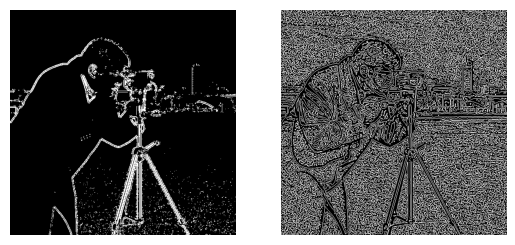

In [ ]:
# --- Task 4: LoG & Zero-Crossing Implementation ---

# Step 1: Smooth the image using Gaussian Blur
# Use cv2.GaussianBlur(src, ksize, sigmaX). Suggested ksize=(5, 5).
# blurred =
blurred = cv2.GaussianBlur(image_f, (5,5), 0)

# Step 2: Apply Laplacian on the blurred image
# Use cv2.Laplacian with ddepth=-1 to maintain float32 type.
# lap_log =
lap_log = cv2.Laplacian(blurred, -1)


# Step 3: Implement Zero-Crossing logic
# A. Find where values are positive: pos = (lap_log > 0)
# B. Use binary_dilation from scipy.ndimage to check neighboring pixels.
# C. Find sign changes using logical XOR: zero_cross = np.logical_xor(pos, binary_dilation(pos))
pos = (lap_log > 0)
zero_cross = np.logical_xor(pos, binary_dilation(pos))

# Step 4: Compare Thresholding vs. Zero-Crossing
# A. Apply a standard threshold to the LoG result: log_thresh = np.abs(lap_log) > 0.05
# B. Plot 'log_thresh' and 'zero_cross' side-by-side.
log_thresh = np.abs(lap_log) > 0.05

plt.subplot(1,2,1)
plt.imshow(log_thresh, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(zero_cross, cmap='gray')
plt.axis('off')

plt.show()

**Q4: In Task 4, you applied a Gaussian Blur before the Laplacian (LoG). If you increase the size of the Gaussian kernel (e.g., from 3x3 to 9x9), how does this affect the detected edges? Specifically, what happens to the fine details and the noise in the image?** *Answer:*Increasing the Gaussian kernel size makes the image more blurred, which reduces noise and removes fine details. As a result, the LoG detects smoother, less detailed edges, focusing more on large structures and ignoring small textures.

### Task 5: Canny Edge & Hough Transform
This task demonstrates high-level feature extraction using the Canny detector and Probabilistic Hough Transform.

### **🚀 What is Canny Edge Detection?**

Think of Canny Edge Detection as the **"Smartest Edge Detector"** available in Image Processing. While Laplacian and Sobel are simple derivative filters, **Canny** is a multi-stage algorithm designed to find the "perfect" edges.

**Why are we using it here?**
In our previous tasks (Sobel & Laplacian), we noticed two main problems:
1. **Noise:** Simple filters get distracted by small dots and noise.
2. **Thick Edges:** Thresholding creates thick, messy lines.

**Canny solves this by doing 4 steps internally:**
1. **Smoothing:** It automatically removes noise.
2. **Gradient Calculation:** It finds the edge strength (like Sobel).
3. **Non-Maximum Suppression:** It thins the edges down to 1-pixel width (even better than Zero-crossing).
4. **Hysteresis Thresholding:** It decides which edges are strong (real) and which are weak (noise) based on two thresholds.

**In this Lab:** We use Canny to get a clean, final edge map that can be used to detect geometric shapes like lines.

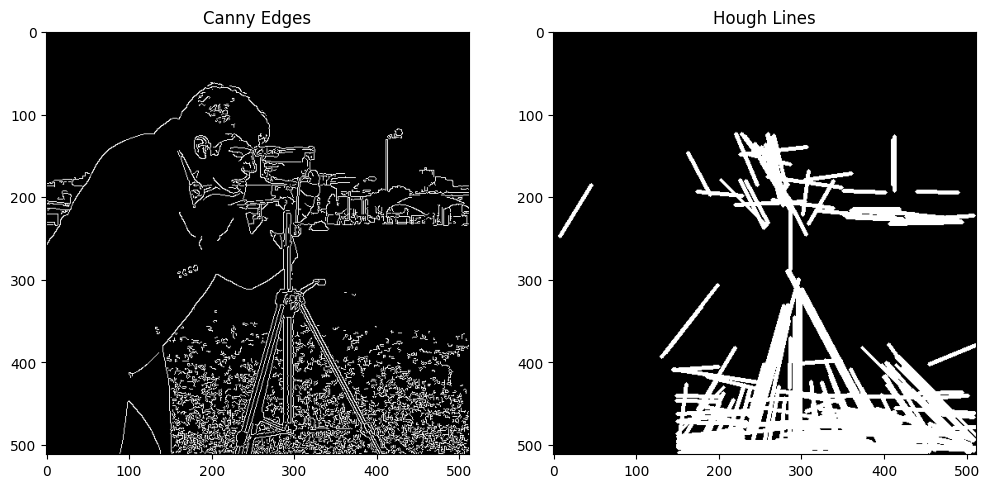

In [ ]:
# 1. Apply Canny Edge Detector on the original uint8 image
edges = cv2.Canny(image, 100, 200)

# 2. Apply Probabilistic Hough Transform to detect lines
# Parameters: rho=1, theta=1 degree, threshold=50, minLineLength=50, maxLineGap=10
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=50, maxLineGap=10)

# 3. Create a blank image to draw lines on
line_image = np.zeros_like(image)

# 4. Draw detected lines
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_image, (x1, y1), (x2, y2), 255, 3)

# 5. Plotting results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(edges, cmap='gray'); plt.title("Canny Edges")
plt.subplot(1, 2, 2); plt.imshow(line_image, cmap='gray'); plt.title("Hough Lines")
plt.show()

**Q5: In the Hough Transform function (`HoughLinesP`), you set a `minLineLength` and a `maxLineGap`. Based on the image result, what happens to the detected lines if you increase the `minLineLength`? Does the result become more "cluttered" with small segments or "cleaner" with only major lines?
**Increasing minLineLength makes the result cleaner, because short line segments are filtered out and only longer, major lines are detected.**

### Task 6: Thresholding Techniques
Comparison between Global Otsu thresholding and Local Adaptive thresholding.

### **🔍 What is Otsu's Thresholding?**

In our first tasks, we had to manually choose a threshold value (like `0.3` or `0.4`). But in real-world images, lighting changes, and picking a manual number is not practical.

**Why use Otsu?**
Otsu’s method is an **Automatic Thresholding** algorithm. It looks at the image's **Histogram** (the distribution of pixel intensities) and automatically finds the "optimal" value to separate the foreground (objects) from the background.

**How it works (Simply):**
1. It analyzes the two peaks in the histogram (one for background, one for objects).
2. It calculates a threshold that minimizes the overlap between these two groups.
3. It gives you a clean binary result without any "trial and error."

**When to use it?** Use Otsu when you have a clear difference between your object and the background (bimodal histogram).

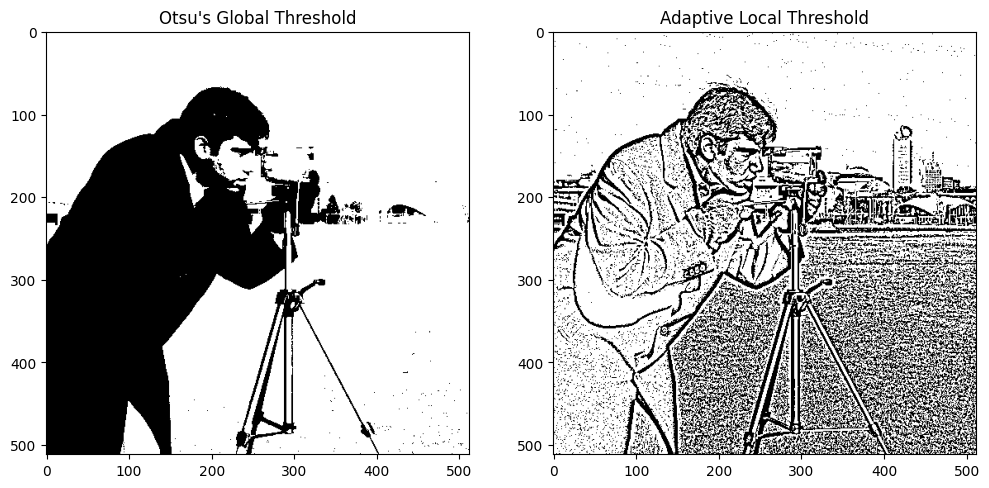

In [ ]:
# 1. Global Thresholding using Otsu's method
ret, otsu_thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Local Thresholding using Adaptive Gaussian method
adaptive_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY, 11, 2)

# 3. Plotting results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(otsu_thresh, cmap='gray'); plt.title("Otsu's Global Threshold")
plt.subplot(1, 2, 2); plt.imshow(adaptive_thresh, cmap='gray'); plt.title("Adaptive Local Threshold")
plt.show()

**Q6: Compare the results of Otsu's (Global) Thresholding and Adaptive (Local) Thresholding. Which method preserved more fine details from the original image (like small text or faint textures), and what is the main visual "artifact" or noise that appears in the background of the Adaptive result?** *Answer:*

### Task 7: Distance Transform & Watershed Segmentation
Generating a distance map, which is a key step for Watershed segmentation.

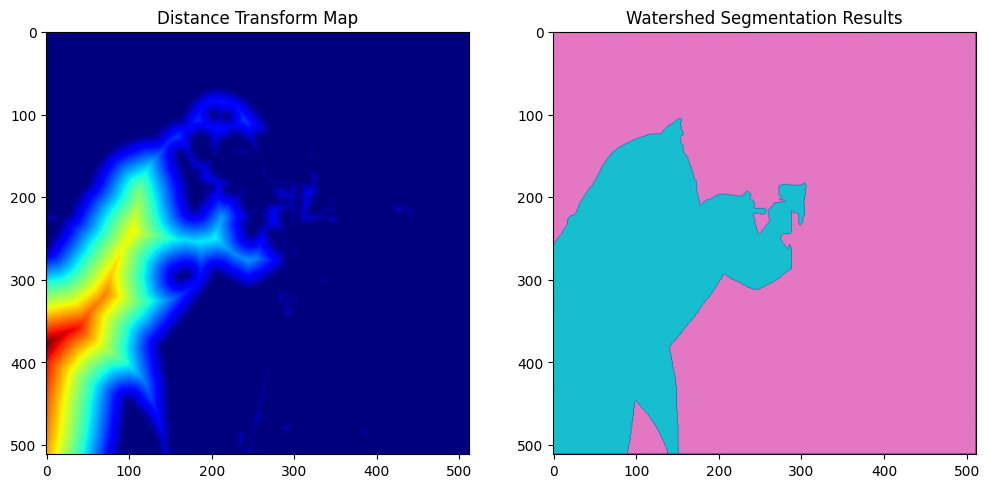

In [ ]:
# --- Task 7: Watershed Segmentation  ---

# 1. Binary Image (Otsu)
ret, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Remove Noise (Optional but recommended)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 3. Finding Sure Background Area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 4. Finding Sure Foreground (Using Distance Transform)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)

# 5. Finding Unknown Region (Boundary)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# 6. Labeling Markers
# Marker 0 is unknown, others are positive integers starting from 1
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1

# Mark the unknown region with zero
markers[unknown == 255] = 0

# 7. Apply Watershed
img_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_color, markers)

# 8. Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(dist_transform, cmap='jet')
plt.title("Distance Transform Map")

plt.subplot(1, 2, 2)
# We color the boundaries (-1) in red to show the segments
img_color[markers == -1] = [255, 0, 0]
plt.imshow(markers, cmap='tab10')
plt.title("Watershed Segmentation Results")
plt.show()

**Q7: Look at the Distance Transform output (the heatmap). Why are the centers of the objects the brightest points in the image? Also, looking at the final Watershed result, how did the algorithm succeed in separating two objects that were originally touching each other?** *Answer:*